In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from linear_regression import LinearRegression

In [3]:
df = pd.read_csv('salary_data.csv')

In [4]:
df.head(5)

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [6]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

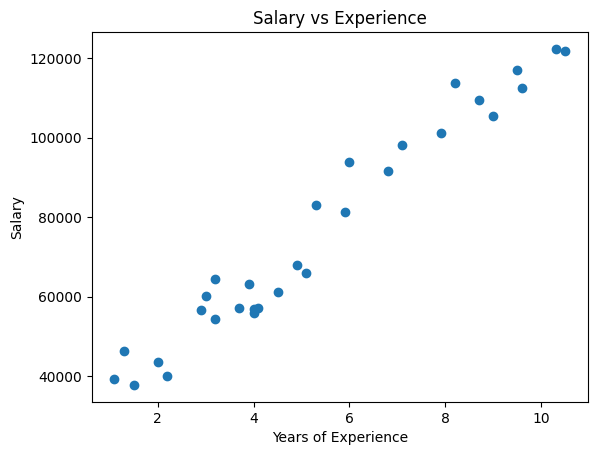

In [7]:
plt.scatter(x=df['YearsExperience'], y=df['Salary'])
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [8]:
X = df['YearsExperience']
y = df['Salary']

In [9]:
print(f"Shape of features: {X.shape}")
print(f"Shape of targets: {y.shape}")

Shape of features: (30,)
Shape of targets: (30,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

#### Training the implemented regression model

In [11]:
custom_model = LinearRegression(learning_rate=0.01, num_iterations=1000)

In [12]:
custom_model.fit(np.array(X_train).reshape(-1, 1), np.array(y_train))

In [13]:
y_pred = custom_model.predict(np.array(X_test).reshape(-1, 1))
y_pred

array([[ 40542.36727474],
       [123430.45261667],
       [ 65032.02885304],
       [ 63148.20873163],
       [115895.17213104],
       [108359.89164541],
       [116837.08219174],
       [ 64090.11879233],
       [ 76334.94958148]])

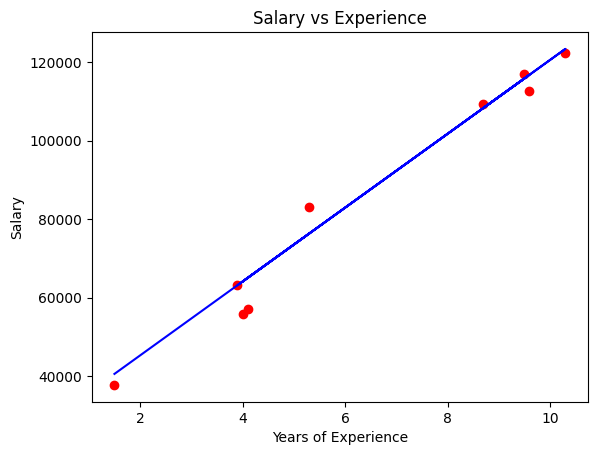

In [14]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, y_pred, color='blue')
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [15]:
def mse_with_gradient(y_true, y_pred):
    n_samples = len(y_true)
    mse = np.mean((y_true - y_pred) ** 2)
    return mse


In [16]:
y_pred.reshape(-1, ).shape

(9,)

In [17]:
custom_mse = mse_with_gradient(y_test, y_pred.reshape(-1, ))

#### Training the sklearn regression model

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [19]:
model = LinearRegression()
model.fit(np.array(X_train).reshape(-1, 1), np.array(y_train))

LinearRegression()

In [20]:
y_pred = model.predict(np.array(X_test).reshape(-1, 1))

In [21]:
y_pred

array([ 40817.78327049, 123188.08258899,  65154.46261459,  63282.41035735,
       115699.87356004, 108211.66453108, 116635.89968866,  64218.43648597,
        76386.77615802])

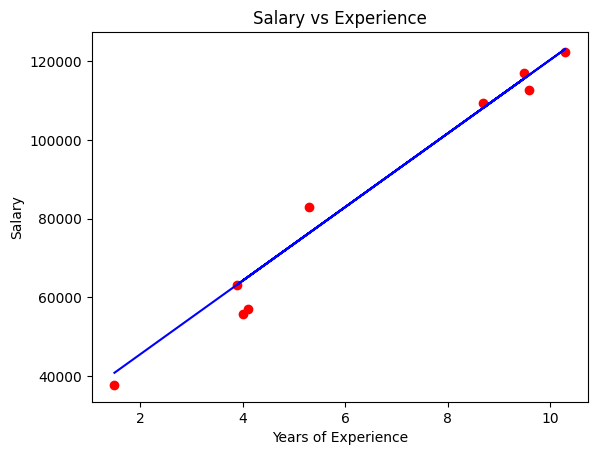

In [22]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, y_pred, color='blue')
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [23]:
sklearn_mse = mean_squared_error(y_test, y_pred.reshape(-1, ))

In [24]:
sklearn_mse > custom_mse

True